# Where should IONNA build next? County-level EV fast-charging site selection

**Team:** Pat Cronin, TJ Mei, Arohi Singh  |  **Industry:** Energy

This file is the annotated, self-contained version of the model behind the app
(https://evchargingmodel-ui5fwbrdxjotcghzbovdvf.streamlit.app/).

**Chunk Table of Contents**
0. Colab setup (only runs in Colab)
1. Setup
2. Load and clean each data source
3. Assign every fast-charging station to a county (spatial join)
4. Build the county-by-year panel (features at end of year t)
5. Define the two targets (outcomes in year t+1)
6. Visualize: market growth, target base rates, and county types (k-means)
7. Model: logistic regression, Lasso, random forest; temporal train/test split
8. Evaluate: test metrics vs. simple baselines, states-held-out CV, 2026 out-of-time check
9. Interpret: odds ratios and feature importance
10. Build cost scenarios from published sources
11. Score counties and select sites under a capital budget
12. Summary of results and limitations

## 0. Running in Google Colab
This chunk installs numbers-parser, which
reads the AFDC laws file saved in Apple Numbers format and downloads the public repo, which holds the raw data.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numbers-parser"], check=True)
    if not os.path.exists("evchargingmodel"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/pc296/evchargingmodel.git"], check=True)
    os.chdir("evchargingmodel")
    print("Colab ready:", os.getcwd())

## 1. Setup
Libraries: pandas/numpy for data, geopandas/shapely for geography, scikit-learn and statsmodels
for models, scipy for the budget optimizer, matplotlib for figures.

In [2]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from numbers_parser import Document
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import BallTree
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140, "display.max_columns", 20)

# Repo root: works as a script (python analysis/...py) and as a notebook opened from analysis/.
_here = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = next(p for p in [_here, *_here.parents] if (p / "data" / "raw").exists())
RAW, EXTERNAL = ROOT / "data" / "raw", ROOT / "data" / "external"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

SEED = 42
EARTH_RADIUS_MI = 3958.8
BLUE, BLUE_LIGHT, ORANGE, AQUA, GRAY = "#2a78d6", "#b7d3f6", "#eb6834", "#1baf7a", "#898781"

STATE_ABBR = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "District of Columbia": "DC",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL",
    "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR",
    "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT", "Virginia": "VA",
    "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
}

## 2. Load and clean each data source

**Unit of analysis:** one U.S. county (50 states + DC, 2025 Census geography: 3,144 counties).

### 2a. County list and FIPS crosswalk
Maps four county codes from the data that no longer exist to current geography so every later join is on the 5-digit FIPS code.

In [3]:
keys = pd.read_csv(RAW / "afdc_ionna_dcfc_by_county_prior.csv")
keys = pd.DataFrame({
    "county_key": keys["County, State Key"].str.strip(),
    "fips": keys["County FIPS"].astype(int).astype(str).str.zfill(5),
    "state": keys["State"],
})
keys = keys[keys["fips"] != "51515"]  # Bedford City, VA: absorbed into Bedford County in 2013
keys.loc[keys["fips"] == "02270", ["fips", "county_key"]] = ["02158", "Kusilvak Census Area, Alaska"]
keys.loc[keys["fips"] == "46113", ["fips", "county_key"]] = ["46102", "Oglala Lakota County, South Dakota"]
valdez = keys[keys["fips"] == "02261"]  # Valdez-Cordova split into two areas in 2019
keys = pd.concat([
    keys[keys["fips"] != "02261"],
    valdez.assign(fips="02063", county_key="Chugach Census Area, Alaska"),
    valdez.assign(fips="02066", county_key="Copper River Census Area, Alaska"),
]).sort_values("fips").reset_index(drop=True)
assert len(keys) == 3144 and keys["fips"].is_unique
print(f"Counties: {len(keys):,}")

Counties: 3,144


### 2b. Population, 2020-2025 (Census Vintage 2025)
The Census file has county names but no FIPS codes. Names differ in capitalization and spacing
("Baltimore city" vs "Baltimore City", "LaSalle" vs "La Salle"), so we match on a normalized name.

In [4]:
def norm_name(s: pd.Series) -> pd.Series:
    s = s.str.lower().str.replace(" ", "", regex=False)
    return s.str.replace("petersburgborough,alaska", "petersburgcensusarea,alaska", regex=False)


raw_pop = pd.read_excel(RAW / "census_pop_2020_2025.xlsx", header=None).iloc[4:, [0, 2, 3, 4, 5, 6, 7]]
raw_pop = raw_pop[raw_pop[0].astype(str).str.startswith(".")]
raw_pop.columns = ["name", 2020, 2021, 2022, 2023, 2024, 2025]
raw_pop["norm"] = norm_name(raw_pop["name"].str.lstrip("."))
pop_wide = raw_pop.merge(keys.assign(norm=norm_name(keys["county_key"]))[["norm", "fips"]], on="norm")
assert len(pop_wide) == 3144, "every county must match a population row"
pop_wide = pop_wide.set_index("fips")[[2020, 2021, 2022, 2023, 2024, 2025]].astype(float)
print(pop_wide.sum().map("{:,.0f}".format))

2020    331,578,104
2021    332,100,166
2022    333,996,304
2023    336,755,052
2024    340,003,797
2025    341,784,857
dtype: str


### 2c. Freeway traffic (FHWA HPMS 2024)
Measure: daily vehicle-miles traveled (VMT) on Interstates and other freeways (functional
classes 1-2), plus interstate miles.

In [5]:
hpms = pd.read_csv(RAW / "hpms_2024_road_utilization.csv")
traffic = pd.DataFrame({
    "fips": hpms["County FIPS"].astype(int).astype(str).str.zfill(5),
    "fwy_vmt": hpms["Highway Daily Vehicle-Miles"].astype(float),
    "fwy_miles": hpms["HPMS Highway Section Miles (F_SYSTEM 1-2)"].astype(float),
    "interstate_miles": hpms["Interstate Section Miles"].astype(float),
})
no_freeway = hpms["HPMS Geography Status"].astype(str).str.startswith("No qualifying")
traffic.loc[no_freeway, ["fwy_vmt", "fwy_miles", "interstate_miles"]] = 0.0  # structural zeros

ct = pd.read_csv(RAW / "hpms_2024_road_utilization_imputed.csv")
ct["fips"] = ct["County FIPS"].astype(int).astype(str).str.zfill(5)
ct = ct[ct["fips"].str.startswith("09")].set_index("fips")
is_ct = traffic["fips"].isin(ct.index)
traffic.loc[is_ct, "fwy_vmt"] = traffic.loc[is_ct, "fips"].map(ct["Final Highway Daily Vehicle-Miles"])
traffic.loc[is_ct, "fwy_miles"] = traffic.loc[is_ct, "fips"].map(ct["Final Highway Section Miles"])
traffic.loc[is_ct, "interstate_miles"] = traffic.loc[is_ct, "fwy_miles"]
traffic["fips"] = traffic["fips"].replace({"02270": "02158", "46113": "46102"})
traffic = traffic[~traffic["fips"].isin(["02261", "51515"])]
traffic = pd.concat([traffic, pd.DataFrame({"fips": ["02063", "02066"], "fwy_vmt": 0.0,
                                            "fwy_miles": 0.0, "interstate_miles": 0.0})])
traffic["has_freeway"] = traffic["fwy_miles"] > 0
assert len(traffic) == 3144 and traffic["fwy_vmt"].notna().all()
print(f"Counties with no interstate/freeway (true zero): {(~traffic['has_freeway']).sum():,}")

Counties with no interstate/freeway (true zero): 1,379


### 2d. State-level inputs: EV registrations, electricity price, EV incentives
* **EV registrations (AFDC):** state battery-EV counts, converted to BEVs per 1,000 residents.
  County-level registrations were not available, so every county in a state gets the state rate
  (a stated limitation).
* **Electricity price (EIA 2024):** all-sector average retail price, cents/kWh.
* **EV incentives (AFDC Laws and Incentives):** count of state incentives tagged to electric
  vehicles that were enacted by year t. Records without an enacted date count in every year.

In [6]:
regs = pd.read_csv(RAW / "afdc_registrations_by_state.csv")
regs = regs[regs["State"].isin(STATE_ABBR)]
state_pop25 = pop_wide[2025].groupby(keys.set_index("fips")["state"]).sum()
regs = pd.DataFrame({"state": regs["State"].map(STATE_ABBR), "bev": regs["Electric (EV)"].astype(float)})
regs["bev_per_1k"] = regs["bev"] / regs["state"].map(state_pop25) * 1000

elec = pd.read_csv(RAW / "eia_state_profile_2024.csv")
elec = elec[elec["Name"].isin(STATE_ABBR)]
elec = pd.DataFrame({"state": elec["Name"].map(STATE_ABBR),
                     "elec_price_c_kwh": elec["Average retail price (cents/kWh)"].astype(float)})

laws_tbl = Document(str(RAW / "afdc_laws_incentives.numbers")).sheets[0].tables[0].rows(values_only=True)
laws = pd.DataFrame(laws_tbl[1:], columns=laws_tbl[0])
ev_inc = laws[laws["Technology Categories"].str.contains("ELEC", na=False)
              & laws["Type"].isin(["State Incentives", "Incentives"])
              & (laws["State"] != "US") & ~laws["Status"].isin(["archived", "expired"])].copy()
ev_inc["enacted_year"] = pd.to_datetime(ev_inc["Enacted Date"].astype(str).str[:10], errors="coerce").dt.year
print(regs.sort_values("bev_per_1k", ascending=False).head(5).round(1))
print(f"EV incentive records used: {len(ev_inc):,}")

   state        bev  bev_per_1k
4     CA  1843100.0        46.8
47    WA   236400.0        29.5
5     CO   162800.0        27.1
28    NV    85600.0        26.1
11    HI    35100.0        24.5
EV incentive records used: 292


### 2e. Charging stations (AFDC, snapshot 2026-09-22)
We keep public stations with at least one DC fast port that are open or temporarily
unavailable. A site with 4+ DC ports is a "large" site, the format IONNA builds (its current
sites average 8.5 ports). Opening dates let us rebuild supply for any past year.

In [7]:
st = pd.read_csv(RAW / "afdc_stations_2026-09-22.csv", low_memory=False)
st = st[st["EV DC Fast Count"].fillna(0) > 0]
st = pd.DataFrame({
    "name": st["Station Name"], "state": st["State"], "lat": st["Latitude"], "lon": st["Longitude"],
    "dc_ports": st["EV DC Fast Count"].astype(int), "network": st["EV Network"].fillna("Unknown"),
    "status": st["Status Code"], "open_year": pd.to_datetime(st["Open Date"], errors="coerce").dt.year,
    "pricing": st["EV Pricing"],
})
st = st[st["status"].isin(["E", "T"]) & ~st["name"].str.contains("NOT A PUBLIC", case=False, na=False)]
st["open_year_filled"] = st["open_year"].fillna(2010).astype(int)  # few missing: assume pre-panel
st["is_large"] = st["dc_ports"] >= 4
st["is_ionna"] = st["network"].str.upper().eq("IONNA")
st["is_tesla"] = st["network"].str.contains("Tesla", case=False)
print(f"DC fast stations: {len(st):,}  |  ports: {st['dc_ports'].sum():,}  |  "
      f"IONNA sites: {st['is_ionna'].sum()}  |  missing open date: {st['open_year'].isna().sum()}")

DC fast stations: 15,941  |  ports: 77,191  |  IONNA sites: 180  |  missing open date: 1


## 3. Assign every station to a county (spatial join)
Here each
station's coordinates are matched to 2023 Census county boundaries (point-in-polygon). Stations
just offshore snap to the nearest county within 5 km. Puerto Rico is out of scope and drops out.

In [8]:
counties = gpd.read_file(EXTERNAL / "us_atlas_2023_counties-10m.json", layer="counties")
counties = counties.rename(columns={"id": "fips"}).set_crs(4326, allow_override=True)
counties = counties[counties["fips"].isin(keys["fips"])].copy()
albers = counties.to_crs(5070)  # equal-area projection for areas and centroids
counties["area_sqmi"] = albers.area / 2.59e6
cent = albers.centroid.to_crs(4326)
counties["cent_lat"], counties["cent_lon"] = cent.y.values, cent.x.values
# Falls Church city, VA is too small to survive map simplification: use its published centroid.
fc = (counties["fips"] == "51610") & counties.geometry.is_empty
counties.loc[fc, ["cent_lat", "cent_lon", "area_sqmi"]] = [38.8847, -77.1751, 2.0]

pts = gpd.GeoDataFrame(st, geometry=gpd.points_from_xy(st["lon"], st["lat"]), crs=4326)
joined = gpd.sjoin(pts, counties[["fips", "geometry"]], predicate="within", how="left")
joined = joined[~joined.index.duplicated()]
miss = joined["fips"].isna()
near = gpd.sjoin_nearest(pts.loc[miss].to_crs(5070), counties[["fips", "geometry"]].to_crs(5070),
                         how="left", max_distance=5000)
joined.loc[miss, "fips"] = near[~near.index.duplicated()]["fips"]
print(f"Within a county: {(~miss).sum():,}  |  snapped: {joined.loc[miss, 'fips'].notna().sum()}  |  "
      f"dropped (outside 50 states + DC): {joined['fips'].isna().sum()}")
st = pd.DataFrame(joined[joined["fips"].notna()].drop(columns=["geometry", "index_right"]))

Within a county: 15,923  |  snapped: 16  |  dropped (outside 50 states + DC): 2


## 4. Build the county-by-year panel
One row per county per year t = 2020-2025, describing the county at the end of year t.
Supply is cumulative: every station open by year t. Two geographic measures use great-circle
distance from the county centroid: miles to the nearest large site, and DC ports within 50 miles
(the spacing used by the federal NEVI corridor program).

In [9]:
base = keys.merge(counties[["fips", "cent_lat", "cent_lon", "area_sqmi"]], on="fips")


def nearest_miles(lat, lon, tlat, tlon):
    tree = BallTree(np.radians(np.c_[tlat, tlon]), metric="haversine")
    return tree.query(np.radians(np.c_[lat, lon]), k=1)[0][:, 0] * EARTH_RADIUS_MI


def ports_within(lat, lon, tlat, tlon, ports, miles):
    tree = BallTree(np.radians(np.c_[tlat, tlon]), metric="haversine")
    idx = tree.query_radius(np.radians(np.c_[lat, lon]), r=miles / EARTH_RADIUS_MI)
    return np.array([ports[i].sum() for i in idx])


def supply_at(t: int) -> pd.DataFrame:
    s = st[st["open_year_filled"] <= t]
    big = s[s["is_large"]]
    g = s.groupby("fips")
    out = pd.DataFrame(index=base["fips"])
    out["dcfc_ports"] = g["dc_ports"].sum()
    out["large_sites"] = big.groupby("fips").size()
    out["tesla_ports"] = s[s["is_tesla"]].groupby("fips")["dc_ports"].sum()
    out["ionna_sites"] = s[s["is_ionna"]].groupby("fips").size()
    out["new_large_sites_t"] = big[big["open_year_filled"] == t].groupby("fips").size()
    out = out.fillna(0).reset_index()
    out["dist_large_dcfc_mi"] = nearest_miles(base["cent_lat"], base["cent_lon"], big["lat"], big["lon"])
    out["ports_within_50mi"] = ports_within(base["cent_lat"], base["cent_lon"], s["lat"], s["lon"],
                                            s["dc_ports"].values, 50)
    return out


YEARS, SNAPSHOT = list(range(2020, 2026)), 2026  # 2026 = supply as of the Sept 22 snapshot
panel = pd.concat([base.merge(supply_at(t), on="fips").assign(year=t) for t in YEARS + [SNAPSHOT]])

pop_wide[SNAPSHOT] = pop_wide[2025]
panel["pop"] = [pop_wide.at[f, y] for f, y in zip(panel["fips"], panel["year"], strict=True)]
panel["pop_growth"] = [pop_wide.at[f, y] / pop_wide.at[f, y - 1] - 1 if 2020 < y <= 2025 else np.nan
                       for f, y in zip(panel["fips"], panel["year"], strict=True)]
panel.loc[panel["year"] == SNAPSHOT, "pop_growth"] = panel.loc[panel["year"] == 2025, "pop_growth"].values
panel = (panel.merge(traffic, on="fips").merge(regs[["state", "bev_per_1k"]], on="state")
         .merge(elec, on="state"))
panel["ev_incentives"] = [
    int(((ev_inc["State"] == s) & ((ev_inc["enacted_year"] <= t) | ev_inc["enacted_year"].isna())).sum())
    for s, t in zip(panel["state"], panel["year"], strict=True)]

panel["bev_est"] = panel["bev_per_1k"] * panel["pop"] / 1000  # state rate x county population
panel["ports_per_1k_bev"] = panel["dcfc_ports"] / panel["bev_est"].clip(lower=1) * 1000
panel["tesla_share"] = np.where(panel["dcfc_ports"] > 0, panel["tesla_ports"] / panel["dcfc_ports"].clip(lower=1), 0)
state_yr = panel.groupby(["state", "year"]).agg(n=("new_large_sites_t", "sum"), p=("pop", "sum"))
state_yr["state_new_large_per_1m"] = state_yr["n"] / state_yr["p"] * 1e6
panel = panel.merge(state_yr[["state_new_large_per_1m"]].reset_index(), on=["state", "year"])

# Model-ready transformations: logs tame heavy right tails (a few metros dominate raw counts).
panel["log_pop"] = np.log(panel["pop"])
panel["log_density"] = np.log((panel["pop"] / panel["area_sqmi"]).clip(lower=0.1))
panel["log_fwy_vmt"] = np.log1p(panel["fwy_vmt"])
panel["has_freeway"] = panel["has_freeway"].astype(float)
for src, dst in [("interstate_miles", "log_interstate_miles"), ("dcfc_ports", "log_dcfc_ports"),
                 ("large_sites", "log_large_sites"), ("ports_per_1k_bev", "log_ports_per_1k_bev"),
                 ("dist_large_dcfc_mi", "log_dist_large_dcfc"), ("ports_within_50mi", "log_ports_50mi"),
                 ("new_large_sites_t", "log_new_large_t")]:
    panel[dst] = np.log1p(panel[src])
print(panel.groupby("year")[["dcfc_ports", "large_sites"]].sum().astype(int))

      dcfc_ports  large_sites
year                         
2020       14508         1466
2021       19850         2014
2022       26670         2658
2023       37696         3716
2024       50725         5148
2025       67611         6973
2026       77189         8118


## 5. Define the two targets
Features describe year t; outcomes are observed in year t+1
* **Target A (`y_new_site`)**: the county gains at least one new DC site with 4+ ports in t+1.
  Answers "where is the market expanding?"
* **Target B (`y_first_site`)**: among counties with no 4+ port site at the end of t, the first
  one opens in t+1. Answers "where is the market about to enter?"

In [10]:
nxt = panel[["fips", "year", "new_large_sites_t"]].assign(year=lambda d: d["year"] - 1)
panel = panel.merge(nxt.rename(columns={"new_large_sites_t": "new_next"}), on=["fips", "year"], how="left")
panel.loc[panel["year"] >= 2025, "new_next"] = np.nan  # 2026 is a partial year: not a label
panel["y_new_site"] = np.where(panel["new_next"].isna(), np.nan, (panel["new_next"] > 0).astype(float))
panel["y_first_site"] = np.where(panel["large_sites"] == 0, panel["y_new_site"], np.nan)

current = panel[panel["year"] == SNAPSHOT].copy()
panel = panel[panel["year"] < SNAPSHOT].copy()
rates = panel.groupby("year")[["y_new_site", "y_first_site"]].mean()
print((rates * 100).round(1).rename(columns=lambda c: c + " (%)"))

      y_new_site (%)  y_first_site (%)
year                                  
2020            10.1               4.6
2021            11.0               4.5
2022            17.1               7.2
2023            21.5               8.5
2024            23.3               7.6
2025             NaN               NaN


## 6. Visualize
### 6a. The market is growing fast
New large sites per year and the share of counties that received one. The rising base rate
matters for evaluation: 2025 (our test year) is busier than the training years.

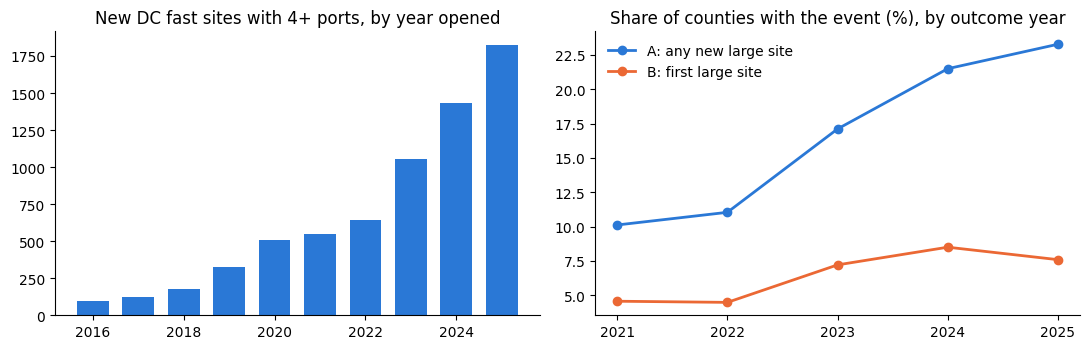

In [11]:
new_per_year = st[st["is_large"] & st["open_year"].between(2016, 2025)].groupby("open_year").size()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(new_per_year.index.astype(int), new_per_year.values, color=BLUE, width=0.7)
ax[0].set_title("New DC fast sites with 4+ ports, by year opened")
ax[0].spines[["top", "right"]].set_visible(False)
lab = rates.dropna().index + 1
ax[1].plot(lab, rates["y_new_site"].dropna() * 100, color=BLUE, lw=2, marker="o", label="A: any new large site")
ax[1].plot(lab, rates["y_first_site"].dropna() * 100, color=ORANGE, lw=2, marker="o", label="B: first large site")
ax[1].set_title("Share of counties with the event (%), by outcome year")
ax[1].set_xticks(list(lab))
ax[1].legend(frameon=False)
ax[1].spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "01_market_growth_and_base_rates.png", dpi=160)

### 6b. County types (unsupervised: k-means)
Seven standardized features describing current conditions; k = 5 clusters, named by rules
applied to the cluster centers. This groups counties into market archetypes for the story,
and is separate from the predictive models.

                                     log_pop  log_density  log_fwy_vmt  bev_per_1k  log_ports_per_1k_bev  log_dist_large_dcfc  pop_growth  \
name                                                                                                                                        
Metro and suburban                      1.23         1.24         0.95        0.15                  0.51                -1.09        0.63   
Small town, underserved                -0.28        -0.08        -0.54       -0.26                 -0.87                 0.50        0.13   
Remote, charging desert                -1.24        -1.29        -0.95       -0.35                 -0.79                 1.16       -0.82   
Counties in high-EV-adoption states     0.50        -0.12         0.27        2.95                  0.45                -0.13       -0.02   
Highway corridor, well supplied        -0.01        -0.08         0.40       -0.27                  1.04                -0.39       -0.14   

            

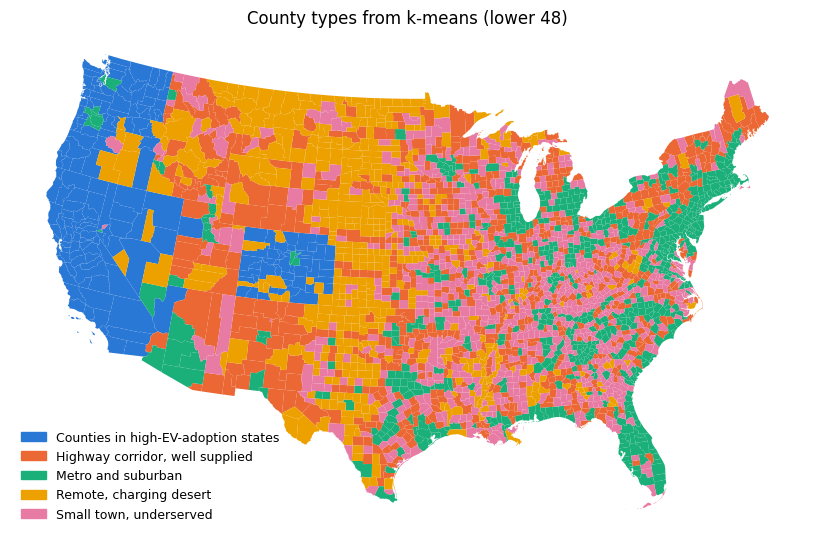

In [12]:
CLUSTER_FEATURES = ["log_pop", "log_density", "log_fwy_vmt", "bev_per_1k",
                    "log_ports_per_1k_bev", "log_dist_large_dcfc", "pop_growth"]
Xc = StandardScaler().fit_transform(current[CLUSTER_FEATURES].fillna(0))
km = KMeans(n_clusters=5, n_init=20, random_state=SEED).fit(Xc)
centers = pd.DataFrame(km.cluster_centers_, columns=CLUSTER_FEATURES)


def cluster_name(c):
    if c["bev_per_1k"] > 1.5:
        return "Counties in high-EV-adoption states"
    if c["log_pop"] > 1.0:
        return "Metro and suburban"
    if c["log_dist_large_dcfc"] > 1.0:
        return "Remote, charging desert"
    if c["log_ports_per_1k_bev"] > 0.8:
        return "Highway corridor, well supplied"
    if c["log_ports_per_1k_bev"] < -0.5:
        return "Small town, underserved"
    return "Mixed"


names = {i: cluster_name(c) for i, c in centers.iterrows()}
current["cluster"] = [names[i] for i in km.labels_]
print(centers.round(2).assign(name=names.values(), n=np.bincount(km.labels_)).set_index("name"))

palette = dict(zip(sorted(set(names.values())), [BLUE, ORANGE, AQUA, "#eda100", "#e87ba4"], strict=True))
cmap = counties.merge(current[["fips", "cluster"]], on="fips")
cmap = cmap[~cmap["fips"].str[:2].isin(["02", "15"])]  # lower 48 for the static figure
fig, ax = plt.subplots(figsize=(11, 6.5))
for name, grp in cmap.groupby("cluster"):
    grp.to_crs(5070).plot(ax=ax, color=palette[name], linewidth=0, label=name)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()],
          labels=list(palette), loc="lower left", frameon=False, fontsize=9)
ax.set_axis_off()
ax.set_title("County types from k-means (lower 48)")
fig.savefig(FIG / "02_county_types_map.png", dpi=160, bbox_inches="tight")

## 7. Model
**Temporal split (no random split).** Train on features from 2021-2023 (outcomes 2022-2024);
test on 2024 features (2025 outcomes). A random split would let the model learn from the same
county's later years and from its neighbors, overstating accuracy.

**Three methods:**
* Logistic regression: the main model. Interpretable odds ratios; the course baseline.
* Lasso (L1) logistic regression: same form, penalty chosen by 5-fold CV; tests whether a
  smaller feature set predicts as well.
* Random forest: allows non-linear effects and interactions; tests whether the linear form sacrifices potential accuracy.

In [13]:
FEATURES = ["log_pop", "pop_growth", "log_density", "bev_per_1k", "elec_price_c_kwh", "ev_incentives",
            "log_fwy_vmt", "has_freeway", "log_interstate_miles", "log_dcfc_ports", "log_large_sites",
            "log_ports_per_1k_bev", "tesla_share", "log_dist_large_dcfc", "log_ports_50mi",
            "log_new_large_t", "state_new_large_per_1m"]
TRAIN_YEARS, TEST_YEAR = [2021, 2022, 2023], 2024
LABELS = {
    "log_pop": "Population (log)", "pop_growth": "Population growth (1 yr)",
    "log_density": "Population density (log)", "bev_per_1k": "State BEVs per 1,000 residents",
    "elec_price_c_kwh": "Electricity price (c/kWh)", "ev_incentives": "State EV incentives",
    "log_fwy_vmt": "Freeway vehicle-miles (log)", "has_freeway": "Has interstate/freeway",
    "log_interstate_miles": "Interstate miles (log)", "log_dcfc_ports": "DC fast ports (log)",
    "log_large_sites": "Large DC sites (log)", "log_ports_per_1k_bev": "DC ports per 1k BEVs (log)",
    "tesla_share": "Tesla share of DC ports", "log_dist_large_dcfc": "Miles to nearest large site (log)",
    "log_ports_50mi": "DC ports within 50 mi (log)", "log_new_large_t": "New large sites this year (log)",
    "state_new_large_per_1m": "State new large sites per 1M pop",
}


def make_models():
    return {
        "logit": make_pipeline(StandardScaler(), LogisticRegression(C=1e6, max_iter=5000)),
        "lasso": make_pipeline(StandardScaler(), LogisticRegressionCV(
            Cs=20, penalty="l1", solver="saga", scoring="roc_auc", max_iter=5000, cv=5, random_state=SEED)),
        "forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=20, max_features=0.5,
                                         n_jobs=-1, random_state=SEED),
    }


def split(target):
    d = panel.dropna(subset=[target] + FEATURES)
    return d[d["year"].isin(TRAIN_YEARS)], d[d["year"] == TEST_YEAR], d


fitted, preds = {}, {}
for tgt in ["y_new_site", "y_first_site"]:
    tr, te, _ = split(tgt)
    for name, m in make_models().items():
        fitted[(tgt, name)] = m.fit(tr[FEATURES], tr[tgt])
        preds[(tgt, name)] = m.predict_proba(te[FEATURES])[:, 1]
    print(f"{tgt}: train n={len(tr):,} (positives {int(tr[tgt].sum()):,}), "
          f"test n={len(te):,} (positives {int(te[tgt].sum()):,})")

y_new_site: train n=9,432 (positives 1,561), test n=3,144 (positives 732)


y_first_site: train n=6,604 (positives 439), test n=1,885 (positives 143)


## 8. Evaluate
### 8a. Test-year metrics against simple baselines
* **ROC AUC**: chance a random positive county ranks above a random negative one.
* **PR AUC**: precision-recall area; more informative when positives are rare (Target B).
* **Precision in top N**: of the N highest-ranked counties (N = actual number of positives),
  the share that really got a site. This is closest to how a planner would use the ranking.
* **Brier score**: mean squared error of the probabilities (calibration + sharpness).

Baselines rank counties by one variable: population, freeway traffic, or existing ports.


Target A (test = 2025 outcomes, base rate 23.3%)
                        ROC AUC  PR AUC  Precision top N  Brier
logit                     0.884   0.738            0.642  0.108
lasso                     0.885   0.742            0.654  0.109
forest                    0.883   0.741            0.646  0.109
rank by population        0.852   0.712            0.624    NaN
rank by freeway VMT       0.841   0.704            0.622    NaN
rank by existing ports    0.847   0.707            0.638    NaN

Target B (test = 2025 outcomes, base rate 7.6%)
                        ROC AUC  PR AUC  Precision top N  Brier
logit                     0.817   0.315            0.357  0.061
lasso                     0.818   0.315            0.364  0.060
forest                    0.818   0.319            0.350  0.061
rank by population        0.772   0.278            0.294    NaN
rank by freeway VMT       0.753   0.263            0.280    NaN
rank by existing ports    0.638   0.146            0.182    NaN


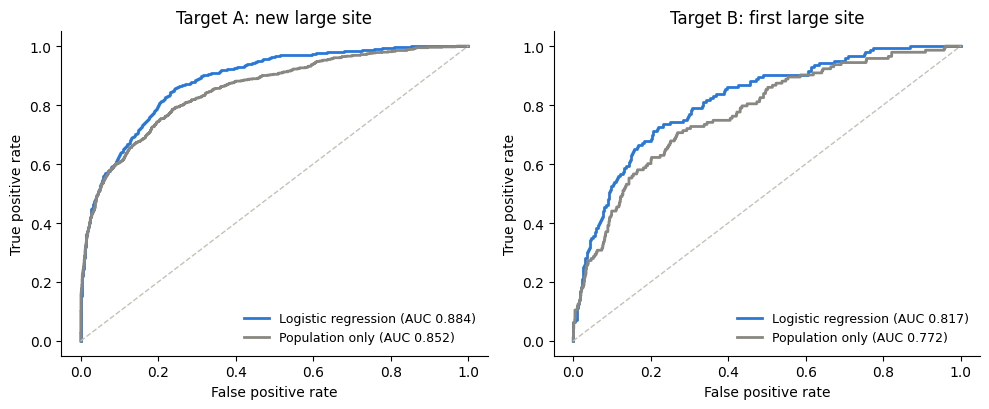

In [14]:
def evaluate(y, p):
    n_pos = int(y.sum())
    top = np.argsort(-p)[:n_pos]
    return {"ROC AUC": roc_auc_score(y, p), "PR AUC": average_precision_score(y, p),
            "Precision top N": y[top].mean(),
            "Brier": brier_score_loss(y, p) if p.max() <= 1 and p.min() >= 0 else np.nan}


results = {}
for tgt, label in [("y_new_site", "A"), ("y_first_site", "B")]:
    _, te, _ = split(tgt)
    y = te[tgt].values
    rows = {name: evaluate(y, preds[(tgt, name)]) for name in ["logit", "lasso", "forest"]}
    for name, col in [("rank by population", "log_pop"), ("rank by freeway VMT", "log_fwy_vmt"),
                      ("rank by existing ports", "log_dcfc_ports")]:
        r = evaluate(y, pd.Series(te[col].values).rank(pct=True, method="first").values)
        r["Brier"] = np.nan  # ranks are not probabilities
        rows[name] = r
    results[label] = pd.DataFrame(rows).T
    print(f"\nTarget {label} (test = 2025 outcomes, base rate {y.mean():.1%})")
    print(results[label].round(3))

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for i, (tgt, label) in enumerate([("y_new_site", "A: new large site"), ("y_first_site", "B: first large site")]):
    _, te, _ = split(tgt)
    for p, name, color in [(preds[(tgt, "logit")], "Logistic regression", BLUE),
                           (te["log_pop"].values, "Population only", GRAY)]:
        fpr, tpr, _ = roc_curve(te[tgt], p)
        ax[i].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC {roc_auc_score(te[tgt], p):.3f})")
    ax[i].plot([0, 1], [0, 1], color="#c3c2b7", lw=1, ls="--")
    ax[i].set(title=f"Target {label}", xlabel="False positive rate", ylabel="True positive rate")
    ax[i].legend(frameon=False, loc="lower right", fontsize=9)
    ax[i].spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "03_roc_curves.png", dpi=160)

### 8b. Robustness: hold out whole states
Five folds, each holding out a group of states entirely (all labeled years). If the model only
worked because it memorized state-level patterns, AUC would fall sharply here.

In [15]:
for tgt in ["y_new_site", "y_first_site"]:
    d = panel.dropna(subset=[tgt] + FEATURES)
    d = d[d["year"].isin(TRAIN_YEARS + [TEST_YEAR])]
    for name in ["logit", "forest"]:
        aucs = [roc_auc_score(d.iloc[b][tgt], make_models()[name].fit(d.iloc[a][FEATURES], d.iloc[a][tgt])
                              .predict_proba(d.iloc[b][FEATURES])[:, 1])
                for a, b in GroupKFold(n_splits=5).split(d, groups=d["state"])]
        print(f"{tgt:13s} {name:7s} states-held-out AUC: mean {np.mean(aucs):.3f} "
              f"(range {min(aucs):.3f}-{max(aucs):.3f})")

y_new_site    logit   states-held-out AUC: mean 0.878 (range 0.863-0.900)


y_new_site    forest  states-held-out AUC: mean 0.881 (range 0.868-0.903)
y_first_site  logit   states-held-out AUC: mean 0.822 (range 0.799-0.859)


y_first_site  forest  states-held-out AUC: mean 0.822 (range 0.798-0.858)


### 8c. Out-of-time check on 2026
Refit on every labeled year (outcomes 2022-2025), score end-of-2025 features, and compare with
large sites that opened January 1 - September 22, 2026.

In [16]:
latest = panel[panel["year"] == 2025].copy()
final = {}
for tgt in ["y_new_site", "y_first_site"]:
    d = panel.dropna(subset=[tgt] + FEATURES)
    final[tgt] = make_models()["logit"].fit(d[d["year"].isin(TRAIN_YEARS + [TEST_YEAR])][FEATURES],
                                            d[d["year"].isin(TRAIN_YEARS + [TEST_YEAR])][tgt])
latest["p_new_site"] = final["y_new_site"].predict_proba(latest[FEATURES])[:, 1]
latest["p_first_site"] = np.where(latest["large_sites"] == 0,
                                  final["y_first_site"].predict_proba(latest[FEATURES])[:, 1], 0.0)
opened_2026 = (latest["fips"].map(current.set_index("fips")["new_large_sites_t"]) > 0).astype(int)
no_site = latest["large_sites"] == 0
print(f"2026 partial year: base rate {opened_2026.mean():.1%}")
print(f"  Model A AUC: {roc_auc_score(opened_2026, latest['p_new_site']):.3f}")
print(f"  Model B AUC (counties with no large site): "
      f"{roc_auc_score(opened_2026[no_site], latest.loc[no_site, 'p_first_site']):.3f}")

2026 partial year: base rate 17.0%
  Model A AUC: 0.883
  Model B AUC (counties with no large site): 0.764


## 9. Interpret
Logistic regression on standardized features, so each odds ratio is the change in odds for a
one-standard-deviation increase, holding the others fixed. Features that never vary in a target's
sample (for B, existing large sites are always zero) are dropped from that fit.

**Reading the coefficients.** "Has interstate/freeway" and "Freeway vehicle-miles (log)" must be
read together: a county with no freeway has log VMT of exactly 0, so the indicator absorbs the
jump from none to some freeway while VMT carries the size effect. The indicator's odds ratio
below 1 is an artifact of that coding, not evidence that freeways deter charging. Similarly,
DC ports per 1,000 EVs has an odds ratio above 1: new large sites cluster where charging already
exists (networks follow each other), which is why the Future Deployment score, not the model
alone, handles saturation.


Target A: odds ratio per 1 SD (sorted)
                        odds_ratio  ci_low  ci_high  p_value
log_fwy_vmt                  6.582   2.728   15.880    0.000
log_pop                      3.443   2.722    4.354    0.000
log_ports_per_1k_bev         1.275   1.060    1.532    0.010
state_new_large_per_1m       1.257   1.165    1.356    0.000
log_dcfc_ports               1.153   0.823    1.616    0.407
bev_per_1k                   1.152   1.021    1.299    0.022
log_interstate_miles         1.108   0.959    1.280    0.164
log_ports_50mi               1.096   0.967    1.242    0.151
log_dist_large_dcfc          1.079   0.957    1.218    0.214
ev_incentives                1.064   0.952    1.190    0.272
elec_price_c_kwh             1.058   0.981    1.142    0.143
pop_growth                   1.053   0.974    1.139    0.195
log_large_sites              1.044   0.844    1.291    0.690
log_new_large_t              0.909   0.836    0.988    0.025
tesla_share                  0.887   0.804   

Random forest permutation importance (AUC drop), top 5: {'log_pop': 0.072, 'log_fwy_vmt': 0.035, 'log_dcfc_ports': 0.009, 'log_interstate_miles': 0.006, 'bev_per_1k': 0.003}

Target B: odds ratio per 1 SD (sorted)
                        odds_ratio  ci_low  ci_high  p_value
log_fwy_vmt                  3.370   1.058   10.735    0.040
log_pop                      2.275   1.756    2.948    0.000
state_new_large_per_1m       1.333   1.194    1.488    0.000
log_interstate_miles         1.316   1.098    1.577    0.003
ev_incentives                1.236   1.068    1.431    0.004
log_dcfc_ports               1.188   1.013    1.392    0.034
log_density                  1.105   0.823    1.485    0.507
log_dist_large_dcfc          1.101   0.915    1.324    0.310
pop_growth                   1.065   0.941    1.205    0.319
bev_per_1k                   1.058   0.908    1.233    0.468
elec_price_c_kwh             1.049   0.952    1.155    0.335
log_ports_per_1k_bev         1.000   0.824    1.213   

Random forest permutation importance (AUC drop), top 5: {'log_pop': 0.077, 'log_fwy_vmt': 0.034, 'log_interstate_miles': 0.011, 'ev_incentives': 0.009, 'bev_per_1k': 0.007}


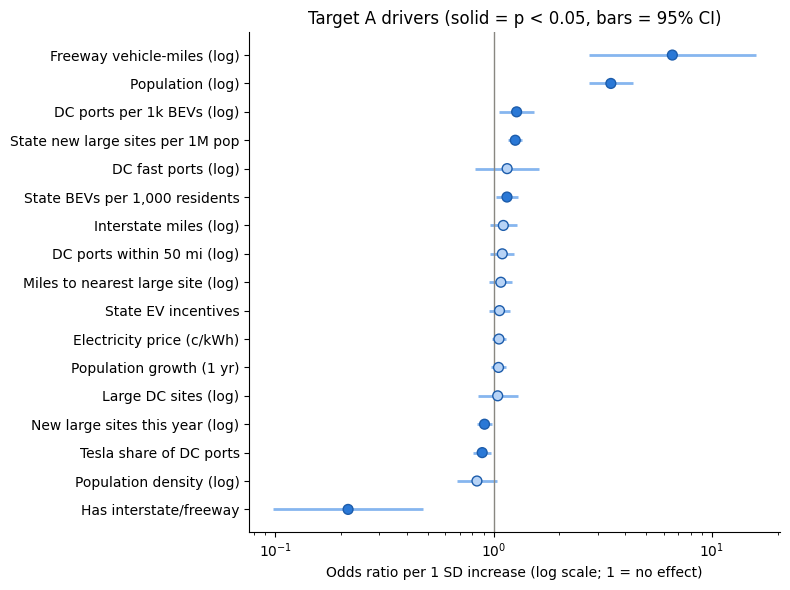

In [17]:
coef_tables = {}
for tgt, label in [("y_new_site", "A"), ("y_first_site", "B")]:
    tr, _, _ = split(tgt)
    feats = [f for f in FEATURES if tr[f].std() > 0]
    Xs = (tr[feats] - tr[feats].mean()) / tr[feats].std()
    res = sm.Logit(tr[tgt].values, sm.add_constant(Xs)).fit(disp=0, maxiter=200)
    tab = pd.DataFrame({"odds_ratio": np.exp(res.params), "ci_low": np.exp(res.conf_int()[0]),
                        "ci_high": np.exp(res.conf_int()[1]), "p_value": res.pvalues}).drop("const")
    coef_tables[label] = tab.sort_values("odds_ratio")
    print(f"\nTarget {label}: odds ratio per 1 SD (sorted)")
    print(tab.sort_values("odds_ratio", ascending=False).round(3))

    lasso = fitted[(tgt, "lasso")][-1]
    kept = [f for f, c in zip(FEATURES, lasso.coef_[0], strict=True) if abs(c) > 1e-6]
    print(f"Lasso kept {len(kept)} of {len(FEATURES)} features: {kept}")
    _, te, _ = split(tgt)
    imp = permutation_importance(fitted[(tgt, "forest")], te[FEATURES], te[tgt], scoring="roc_auc",
                                 n_repeats=5, random_state=SEED, n_jobs=-1)
    print("Random forest permutation importance (AUC drop), top 5:",
          pd.Series(imp.importances_mean, FEATURES).nlargest(5).round(3).to_dict())

tab = coef_tables["A"]
sig = tab["p_value"] < 0.05
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(tab["odds_ratio"], range(len(tab)), xerr=[tab["odds_ratio"] - tab["ci_low"],
            tab["ci_high"] - tab["odds_ratio"]], fmt="none", ecolor="#86b6ef", elinewidth=2)
ax.scatter(tab["odds_ratio"], range(len(tab)), c=np.where(sig, BLUE, BLUE_LIGHT), s=50, zorder=3,
           edgecolors="#1c5cab")
ax.axvline(1, color=GRAY, lw=1)
ax.set_xscale("log")
ax.set_yticks(range(len(tab)), [LABELS[i] for i in tab.index])
ax.set_xlabel("Odds ratio per 1 SD increase (log scale; 1 = no effect)")
ax.set_title("Target A drivers (solid = p < 0.05, bars = 95% CI)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "04_target_A_odds_ratios.png", dpi=160)

## 10. Build cost scenarios
Default site: 8 DC ports (IONNA's current sites average 8.5). Three scenarios from published data:

**Low**: median cost per port across 330 NEVI award applications, all-in (Paren, Oct 2024): \$183,116/port.

**Base**: NREL per-port equipment (\$141,900) + installation (\$90,800) at 350 kW, plus a \$100,000 distribution transformer (Borlaug et al., 2026, Advances in Applied Energy 21).

**High**: Base × the NEVI top-quartile / median project cost ratio (\$1,053,624 / \$802,267) = 1.31.

Excluded: land, feeder or substation upgrades, and regional construction cost differences.

In [18]:
PORTS = 8
TQ_RATIO = 1_053_624 / 802_267
scenarios = pd.DataFrame({
    "per_port": [183_116, 141_900 + 90_800, (141_900 + 90_800) * TQ_RATIO],
    "site_fixed": [0, 100_000, 100_000 * TQ_RATIO]}, index=["Low", "Base", "High"])
scenarios["site_cost"] = scenarios["per_port"] * PORTS + scenarios["site_fixed"]
print(scenarios.round(0).map("${:,.0f}".format))
SITE_COST = scenarios.loc["Base", "site_cost"]

      per_port site_fixed   site_cost
Low   $183,116         $0  $1,464,928
Base  $232,700   $100,000  $1,961,600
High  $305,607   $131,331  $2,576,186


## 11. Score counties and select sites under a budget
**Scores.** Each input becomes a percentile rank (0-1) across counties so weights are comparable.
* Net Opportunity (0-100) = weighted mean of: estimated EVs (0.25), freeway traffic (0.25),
  population growth (0.05), Model A probability (0.20), Model B probability (0.10), state EV
  incentives (0.05), electricity price, lower is better (0.10).
* Future Deployment = Net Opportunity x (1 - 0.5 x saturation), where saturation is the average
  percentile of DC ports per 1,000 EVs and DC ports within 50 miles.

**Selection.** The k-th new site in a county is worth score x 0.5^(existing IONNA sites + k - 1),
up to 2 per county. We maximize total value subject to total cost <= budget. With one cost per
site, taking the highest values is exactly optimal (an integer program for unequal costs is
implemented in the code but not used by the app).

In [19]:
app = current.drop(columns=["pop_growth"]).merge(
    latest[["fips", "pop_growth", "p_new_site", "p_first_site"]], on="fips")


def pct(s, higher_is_better=True):
    r = s.rank(pct=True)
    return r if higher_is_better else 1 - r + 1 / len(s)


WEIGHTS = {("bev_est", True): 0.25, ("fwy_vmt", True): 0.25, ("pop_growth", True): 0.05,
           ("p_new_site", True): 0.20, ("p_first_site", True): 0.10, ("ev_incentives", True): 0.05,
           ("elec_price_c_kwh", False): 0.10}
app["net_opportunity"] = 100 * sum(w * pct(app[c].fillna(app[c].median()), hib)
                                   for (c, hib), w in WEIGHTS.items()) / sum(WEIGHTS.values())
app["saturation"] = (pct(app["ports_per_1k_bev"]) + pct(app["ports_within_50mi"])) / 2
app["future_deployment"] = app["net_opportunity"] * (1 - 0.5 * app["saturation"])

BUDGET, MAX_PER_COUNTY, DECAY = 100e6, 2, 0.5
cand = pd.concat([app[["fips", "county_key", "state", "future_deployment", "ionna_sites"]].assign(
    k=k, value=lambda d, k=k: d["future_deployment"] * DECAY ** (d["ionna_sites"] + k - 1))
    for k in range(1, MAX_PER_COUNTY + 1)])
n_sites = int(BUDGET // SITE_COST)
picks = cand.sort_values(["value", "k"], ascending=[False, True]).head(n_sites)
print(f"Budget ${BUDGET/1e6:,.0f}M at ${SITE_COST/1e6:.2f}M per site -> {n_sites} sites, "
      f"{picks['fips'].nunique()} counties, {picks['state'].nunique()} states")
print(picks[["county_key", "k", "future_deployment"]].head(15).round(1).to_string(index=False))
print("\nPicks by state:", picks["state"].value_counts().head(8).to_dict())

Budget $100M at $1.96M per site -> 50 sites, 50 counties, 15 states
                 county_key  k  future_deployment
      Wichita County, Texas  1               69.2
      Hidalgo County, Texas  1               67.2
      Randall County, Texas  1               66.5
         Webb County, Texas  1               65.6
    Jefferson County, Texas  1               65.4
      Lubbock County, Texas  1               65.1
        Tooele County, Utah  1               64.9
        Ector County, Texas  1               64.8
  Comanche County, Oklahoma  1               63.7
      Midland County, Texas  1               63.1
      El Paso County, Texas  1               62.9
      Cameron County, Texas  1               61.6
       Nueces County, Texas  1               61.5
 Spokane County, Washington  1               61.4
Doña Ana County, New Mexico  1               61.4

Picks by state: {'TX': 19, 'WA': 8, 'UT': 4, 'AZ': 3, 'NM': 2, 'ID': 2, 'CO': 2, 'AR': 2}


## 12. Summary
**What the models show.** Both targets are predictable well above chance (test ROC AUC about 0.88
for A and 0.82 for B), and the result holds with whole states held out and on 2026 openings. The lift over a population-only ranking is moderate (about +0.03 AUC for A and
+0.05 for B): chargers follow people, and the models add traffic, market momentum and gap
information on top. Lasso and random forest do not meaningfully differ from plain logistic regression, which
supports the simpler, interpretable model.

**What the models do not show.** Both targets describe where the market has built, not where a
site earns a return. The scoring layer adds saturation and cost, and the app lets users change
the weights, budget and cost assumptions.

**Limitations.** EV adoption is a state rate applied to every county; electricity price is the
all-sector average rather than the commercial rate with demand charges; closed stations are not
in the station file, so past supply is slightly undercounted; utilization is not observed at the
county level; recommendations are counties, not specific parcels.

**Default result is concentrated in Texas.** State-level inputs (cheap electricity, incentive
counts) move every county in a state together, and Texas has many mid-size metros with few large
sites. Reviewers should test the weights in the app before treating the list as a plan.

In [20]:
if __name__ == "__main__":
    print("\nFigures written to", FIG)


Figures written to /home/claude/evchargingmodel/reports/figures
